In [5]:
import pandas as pd
import numpy as np
import mysql.connector

In [7]:
connection = mysql.connector.connect(
    host = 'Localhost',
    user = 'root',
    password = 'root@123',
    database = 'fintech_risk_analytics')

In [9]:
customers = pd.read_sql(
    "SELECT * FROM customers",
    connection
)

loans = pd.read_sql(
    "SELECT * FROM loans",
    connection
)

repayments = pd.read_sql(
    "SELECT * FROM repayments",
    connection
)

transactions = pd.read_sql(
    "SELECT * FROM transactions",
    connection
)

C:\Users\Shambhu\AppData\Local\Temp\ipykernel_22472\2290677859.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql(
C:\Users\Shambhu\AppData\Local\Temp\ipykernel_22472\2290677859.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  loans = pd.read_sql(
C:\Users\Shambhu\AppData\Local\Temp\ipykernel_22472\2290677859.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  repayments = pd.read_sql(
C:\Users\Shambhu\AppData\Local\Temp\ipykernel_22472\2290677859.py:16: UserWarning: pandas only supports SQLAlch

one powerful merged dataset

In [10]:
#MERGE CUSTOMERS + LOANS
customers_loans = pd.merge(
    customers,
    loans,
    on='customer_id'
)
customers_loans.head()

,customer_id,first_name,last_name,gender,date_of_birth,city,state,employment_type,monthly_income,signup_date,loan_id,loan_amount,interest_rate,tenure_months,loan_status,disbursement_date
0,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,3529,421688.0,12.82,48,Active,2024-07-03
1,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,5269,607834.0,12.95,24,Active,2024-08-25
2,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,6550,826810.0,11.07,24,Closed,2026-04-08
3,3,Nancy,Peters,Female,1972-04-02,Jessicamouth,Tennessee,Self-Employed,150282.0,2025-04-10,618,574604.0,23.32,48,Default,2024-10-28
4,7,Barry,Estrada,Male,1976-06-05,Port Kennethburgh,Arizona,Freelancer,93363.0,2025-03-01,6280,292441.0,9.81,48,Active,2025-07-30


In [12]:
#MERGE REPAYMENTS
customers_loans_repayments = pd.merge(
    customers_loans,
    repayments,
    on='loan_id'
)
customers_loans_repayments.head()


,customer_id,first_name,last_name,gender,date_of_birth,city,state,employment_type,monthly_income,signup_date,...,loan_amount,interest_rate,tenure_months,loan_status,disbursement_date,repayment_id,due_date,payment_date,amount_paid,repayment_status
0,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,421688.0,12.82,48,Active,2024-07-03,17025,2026-03-11,2025-05-16,3758.49,On-Time
1,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,421688.0,12.82,48,Active,2024-07-03,18936,2025-09-04,2025-08-16,9007.61,Late
2,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,826810.0,11.07,24,Closed,2026-04-08,13245,2026-04-29,2026-04-12,38096.19,On-Time
3,3,Nancy,Peters,Female,1972-04-02,Jessicamouth,Tennessee,Self-Employed,150282.0,2025-04-10,...,574604.0,23.32,48,Default,2024-10-28,1962,2026-02-15,2025-05-17,46205.70,Late
4,3,Nancy,Peters,Female,1972-04-02,Jessicamouth,Tennessee,Self-Employed,150282.0,2025-04-10,...,574604.0,23.32,48,Default,2024-10-28,13128,2026-01-26,2025-05-14,2046.68,On-Time


FEATURE ENGINEERING 

## Feature Engineering Insight

Income segmentation enables better customer targeting and helps identify higher-value lending segments.

In [14]:
#FEATURE 1 — INCOME SEGMENT
customers_loans_repayments['income_segment'] = customers_loans_repayments['monthly_income'].apply(lambda x:
                                                            'Low income' if x < 50000 else
                                                            'Middle income' if x < 100000 else
                                                            'High income')
customers_loans_repayments.head()

,customer_id,first_name,last_name,gender,date_of_birth,city,state,employment_type,monthly_income,signup_date,...,interest_rate,tenure_months,loan_status,disbursement_date,repayment_id,due_date,payment_date,amount_paid,repayment_status,income_segment
0,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,12.82,48,Active,2024-07-03,17025,2026-03-11,2025-05-16,3758.49,On-Time,Middle income
1,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,12.82,48,Active,2024-07-03,18936,2025-09-04,2025-08-16,9007.61,Late,Middle income
2,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,11.07,24,Closed,2026-04-08,13245,2026-04-29,2026-04-12,38096.19,On-Time,Middle income
3,3,Nancy,Peters,Female,1972-04-02,Jessicamouth,Tennessee,Self-Employed,150282.0,2025-04-10,...,23.32,48,Default,2024-10-28,1962,2026-02-15,2025-05-17,46205.70,Late,High income
4,3,Nancy,Peters,Female,1972-04-02,Jessicamouth,Tennessee,Self-Employed,150282.0,2025-04-10,...,23.32,48,Default,2024-10-28,13128,2026-01-26,2025-05-14,2046.68,On-Time,High income


In [15]:
#FEATURE 2 — HIGH RISK FLAG
customers_loans_repayments['high_risk_flag'] = customers_loans_repayments['loan_status'].apply(lambda x:
                                                            1 if x == 'Default' else
                                                            0)
customers_loans_repayments.head()

,customer_id,first_name,last_name,gender,date_of_birth,city,state,employment_type,monthly_income,signup_date,...,tenure_months,loan_status,disbursement_date,repayment_id,due_date,payment_date,amount_paid,repayment_status,income_segment,high_risk_flag
0,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,48,Active,2024-07-03,17025,2026-03-11,2025-05-16,3758.49,On-Time,Middle income,0
1,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,48,Active,2024-07-03,18936,2025-09-04,2025-08-16,9007.61,Late,Middle income,0
2,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,24,Closed,2026-04-08,13245,2026-04-29,2026-04-12,38096.19,On-Time,Middle income,0
3,3,Nancy,Peters,Female,1972-04-02,Jessicamouth,Tennessee,Self-Employed,150282.0,2025-04-10,...,48,Default,2024-10-28,1962,2026-02-15,2025-05-17,46205.70,Late,High income,1
4,3,Nancy,Peters,Female,1972-04-02,Jessicamouth,Tennessee,Self-Employed,150282.0,2025-04-10,...,48,Default,2024-10-28,13128,2026-01-26,2025-05-14,2046.68,On-Time,High income,1


In [16]:
#FEATURE 3 — LARGE LOAN FLAG
customers_loans_repayments['large_loan_flag'] = customers_loans_repayments['loan_amount'].apply(lambda x:
                                                            1 if x > 500000 else
                                                            0)
customers_loans_repayments.head()

,customer_id,first_name,last_name,gender,date_of_birth,city,state,employment_type,monthly_income,signup_date,...,loan_status,disbursement_date,repayment_id,due_date,payment_date,amount_paid,repayment_status,income_segment,high_risk_flag,large_loan_flag
0,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,Active,2024-07-03,17025,2026-03-11,2025-05-16,3758.49,On-Time,Middle income,0,0
1,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,Active,2024-07-03,18936,2025-09-04,2025-08-16,9007.61,Late,Middle income,0,0
2,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31,...,Closed,2026-04-08,13245,2026-04-29,2026-04-12,38096.19,On-Time,Middle income,0,1
3,3,Nancy,Peters,Female,1972-04-02,Jessicamouth,Tennessee,Self-Employed,150282.0,2025-04-10,...,Default,2024-10-28,1962,2026-02-15,2025-05-17,46205.70,Late,High income,1,1
4,3,Nancy,Peters,Female,1972-04-02,Jessicamouth,Tennessee,Self-Employed,150282.0,2025-04-10,...,Default,2024-10-28,13128,2026-01-26,2025-05-14,2046.68,On-Time,High income,1,1


## Risk Analytics Insight

Customers with missed repayments and defaulted loan statuses represent higher-risk segments requiring stricter monitoring.

ANALYTICS KPIs

In [20]:
#TOTAL LOAN PORTFOLIO
customers_loans_repayments['loan_amount'].sum()

np.float64(10595145398.0)

In [21]:
#DEFAULT RATE
customers_loans_repayments['high_risk_flag'].mean()*100

np.float64(34.335)

In [22]:
#MISSED PAYMENT RATE
customers_loans_repayments['missed_payment_flag'].mean()*100

np.float64(33.715)

In [23]:
#AVG LOAN BY SEGMENT
customers_loans_repayments.groupby('income_segment')['loan_amount'].mean()

income_segment
High income      530262.908000
Low income       544903.913521
Middle income    521352.448421
Name: loan_amount, dtype: float64

Power BI ready CSVs

In [24]:
#CUSTOMER LOAN ANALYTICS
customers_loans_repayments.to_csv(
    '../data/cleaned/customer_loan_analytics.csv',
    index=False
)

In [28]:
#KPI SUMMARY
kpi_summary = pd.DataFrame({
    'metrics': ['Total Loan Portfolio', 'Default Rate (%)', 'Missed Payment Rate (%)'],
    'values': [
        customers_loans_repayments['loan_amount'].sum(),
        customers_loans_repayments['high_risk_flag'].mean()*100,
        customers_loans_repayments['missed_payment_flag'].mean()*100,
    ]
})
kpi_summary

,metrics,values
0,Total Loan Portfolio,1.059515e+10
1,Default Rate (%),3.433500e+01
2,Missed Payment Rate (%),3.371500e+01


In [29]:
kpi_summary.to_csv(
    '../data/cleaned/kpi_summary.csv',
    index=False
)

CREATE CHARTS

<Axes: xlabel='income_segment'>

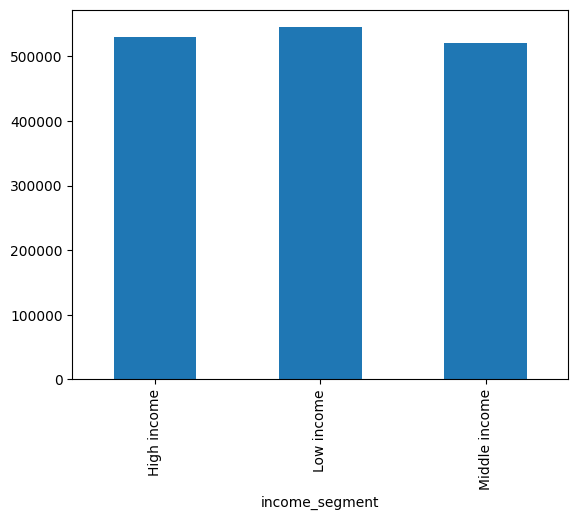

In [30]:
#LOAN AMOUNT BY SEGMENT
customers_loans_repayments.groupby('income_segment')['loan_amount'].mean().plot(kind='bar')

<Axes: >

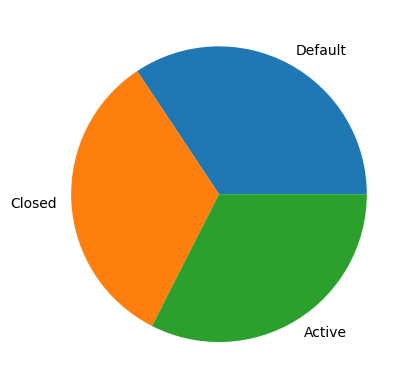

In [32]:
#RISK DISTRIBUTION
customers_loans_repayments[
    'loan_status'
].value_counts().plot(kind='pie')

<Axes: xlabel='repayment_status'>

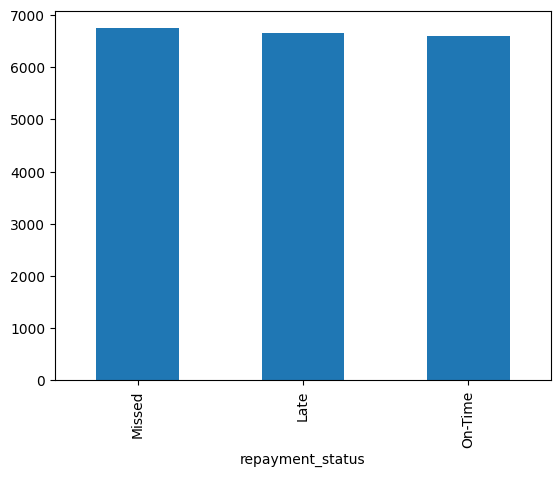

In [33]:
#MISSED PAYMENT ANALYSIS
customers_loans_repayments[
    'repayment_status'
].value_counts().plot(kind='bar')